In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm         
from pathlib import Path

FIG_DIR = Path("report/figures")  
FIG_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(2503)

In [ ]:
import yfinance as yf
import pandas as pd

DATA_FILE = Path("data/nvda_close.csv")  
REFRESH = False                        

def fetch_last_close(ticker="NVDA"):
    hist = yf.Ticker(ticker).history(period="5d", auto_adjust=False)
    return pd.DataFrame({
        "date":   [hist.index[-1].date()],             # date of the most recent row
        "close":  [round(float(hist["Close"].iloc[-1]), 2)],
        "source": ["Yahoo Finance (yfinance)"],
    })

if REFRESH or not DATA_FILE.exists():     
    fetch_last_close().to_csv(DATA_FILE, index=False)

price = pd.read_csv(DATA_FILE)
S0 = float(price["close"].iloc[0])
K  = S0
print(price)

         date   close                    source
0  2026-09-30  228.38  Yahoo Finance (yfinance)


## 1. CRR parameters
$\Delta t = T/N$, $u = e^{\sigma\sqrt{\Delta t}}$, $d = 1/u$, $\tilde p = \dfrac{e^{r\Delta t} - d}{u - d}$, with the no-arbitrage check $d < e^{r\Delta t} < u$.

In [3]:
T     = 1.0     # years
r     = 0.04    # risk-free rate (continuous compounding)
sigma = 0.30    # annualised volatility

def crr_parameters(sigma, r, T, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    growth = np.exp(r * dt)
    if not (d < growth < u):
        raise ValueError("No-arbitrage condition d < e^{r dt} < u fails")
    p = (growth - d) / (u - d)

    return dt, u, d, p

## 2. Stock prices on the tree
After $n$ steps with $j$ up-moves: $S_n(j) = S_0\,u^{j}d^{\,n-j}$, $j = 0,\dots,n$.

In [4]:

def prices_at_step(S0, u, d, n): 
    j = np.arange(n+1)
    S_n = S0 * u**j * d**(n-j)
    return S_n

dt, u, d, p = crr_parameters(sigma, r, T, 3)
for n in range(4):
    print(n, np.round(prices_at_step(S0, u, d, n), 2))

0 [228.38]
1 [192.06 271.57]
2 [161.52 228.38 322.93]
3 [135.83 192.06 271.57 383.99]


## 3. Payoff and backward induction
$V_N(j) = (S_N(j) - K)^+$ and $V_n(j) = e^{-r\Delta t}\left[\tilde p\,V_{n+1}(j+1) + (1-\tilde p)\,V_{n+1}(j)\right]$.
Checked against the 3-period example in Lecture 2 ($V_0 = 2.048$).

In [5]:
def call_payoff(S, K):
    payoff = np.maximum(S-K, 0)
    return payoff

In [6]:
def backward_induction(V_T, p, disc_fctr): 
    V = V_T.copy()
    q = 1 - p
    for i in range(len(V_T) - 1):
        V = disc_fctr * ( p * V[1:] + q * V[:-1])
    return V[0]

In [ ]:
V_T = call_payoff(prices_at_step(4, 2, 0.5, 3), 6)
print(V_T)                                              
print(backward_induction(V_T, p=0.5, disc_fctr=1/1.25))

[ 0.  0.  2. 26.]
2.0480000000000005


## 4. Binomial call price (task 2c)

In [8]:
def binomial_call(S0, K, T, r, sigma, N):
    dt, u, d, p = crr_parameters(sigma, r, T, N)
    S_N = prices_at_step(S0, u, d, N)
    V_N = call_payoff(S_N, K)
    return backward_induction(V_N, p, np.exp(-r*dt))

for N in [3, 50, 100]:
    print(N, round(binomial_call(S0, K, T, r, sigma, N), 4))

3 33.5888
50 31.2754
100 31.3425


## 5. Black–Scholes benchmark

In [13]:
def black_scholes_call(S0, K, T, r, sigma): 
    d_plus =((np.log(S0/K) + (r + (1/2) * sigma**2) * T)) / (sigma* np.sqrt(T))
    d_minus = (d_plus - sigma * T ** (1/2))
    return S0 * norm.cdf(d_plus) - K * np.exp(-r * T) * norm.cdf(d_minus)

print(black_scholes_call(S0, K, T, r, sigma))     # expect ≈ 31.4097

31.40970580137487


## 6. Price vs. number of steps (task 2b)

In [16]:
N_values  =  np.arange(1, 301)

prices = [binomial_call(S0, K, T, r, sigma, N) for N in N_values]

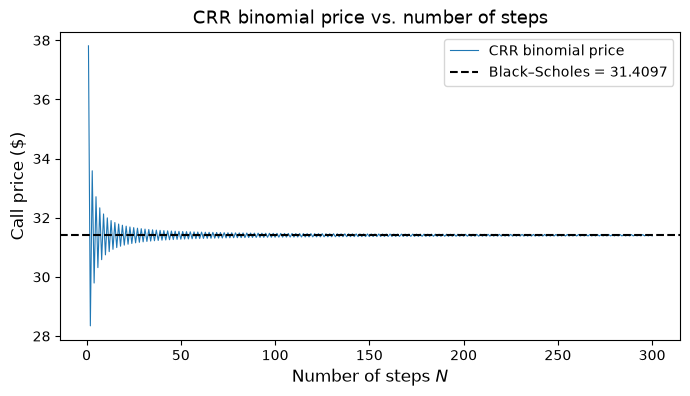

In [17]:
C_bs = black_scholes_call(S0, K, T, r, sigma)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(N_values, prices, linewidth=0.8, label="CRR binomial price")
ax.axhline(C_bs, color="black", linestyle="--", label=f"Black–Scholes = {C_bs:.4f}")   # horizontal reference line
ax.set_xlabel("Number of steps $N$", fontsize=12)
ax.set_ylabel("Call price (\\$)", fontsize=12)
ax.set_title("CRR binomial price vs. number of steps", fontsize=13)
ax.legend()
fig.savefig(FIG_DIR / "part2_binomial_convergence.pdf", bbox_inches="tight")
plt.show()

In [18]:
for N in [10, 50, 100, 500, 1000]:
    price = binomial_call(S0, K, T, r, sigma, N)
    print(f"N = {N:5d}   price = {price:.4f}   error vs BS = {price - C_bs:+.4f}")

N =    10   price = 30.7461   error vs BS = -0.6636
N =    50   price = 31.2754   error vs BS = -0.1343
N =   100   price = 31.3425   error vs BS = -0.0672
N =   500   price = 31.3962   error vs BS = -0.0135
N =  1000   price = 31.4030   error vs BS = -0.0067


## Tree of Stock Prices

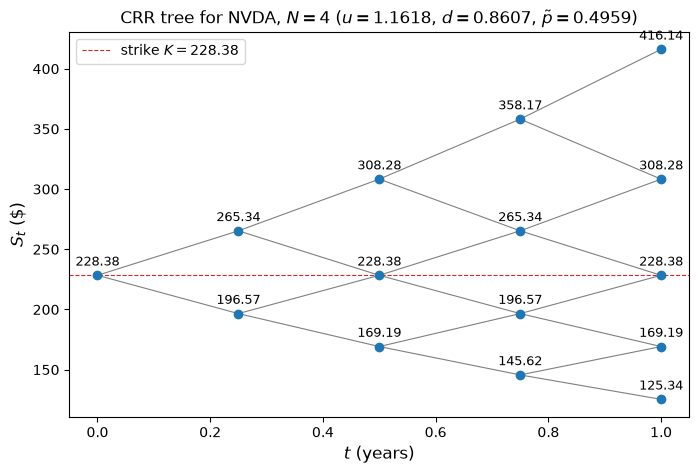

In [19]:
N_small = 4
dt_s, u_s, d_s, p_s = crr_parameters(sigma, r, T, N_small)

fig, ax = plt.subplots(figsize=(8, 5))
for n in range(N_small + 1):                         # each time step n = 0..4
    t_n = n * dt_s                                   # its time in years
    S_n = prices_at_step(S0, u_s, d_s, n)            # all prices at this step
    if n < N_small:                                  # draw branches to the next step
        S_next = prices_at_step(S0, u_s, d_s, n + 1)
        for j in range(n + 1):
            ax.plot([t_n, t_n + dt_s], [S_n[j], S_next[j + 1]], color="grey", linewidth=0.8)  # up branch
            ax.plot([t_n, t_n + dt_s], [S_n[j], S_next[j]],     color="grey", linewidth=0.8)  # down branch
    ax.scatter(np.full(n + 1, t_n), S_n, color="C0", zorder=3)                                # the nodes
    for j in range(n + 1):                                                                    # price labels
        ax.annotate(f"{S_n[j]:.2f}", (t_n, S_n[j]), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=9)

ax.axhline(K, color="C3", linestyle="--", linewidth=0.8, label=f"strike $K = {K:.2f}$")
ax.set_xlabel("$t$ (years)", fontsize=12)
ax.set_ylabel("$S_t$ (\\$)", fontsize=12)
ax.set_title(f"CRR tree for NVDA, $N = {N_small}$ "
             f"($u = {u_s:.4f}$, $d = {d_s:.4f}$, $\\tilde p = {p_s:.4f}$)", fontsize=12)
ax.legend(loc="upper left")
fig.savefig(FIG_DIR / "part2_crr_tree.pdf", bbox_inches="tight")
plt.show()

## Sample Paths of CRR Binomial Model (2a)

In [23]:
def simulate_tree_paths(S0, sigma, r, T, N, n_paths, rng):
    dt, u, d, p = crr_parameters(sigma, r, T, N)
    t = np.linspace(0, T, N + 1)
    up = rng.random(size = (n_paths, N)) < p
    factors = np.where(up , u, d)
    S = S0 * np.cumprod(factors, axis=1)
    S = np.hstack([np.full((n_paths, 1), S0), S]) 
    return t, S

t_chk, S_chk = simulate_tree_paths(S0, sigma, r, T, 100, 100_000, np.random.default_rng(0))
print(S_chk.shape)                                   # (100000, 101)
print(S_chk[:, -1].mean(), S0 * np.exp(r * T))       # both ≈ 237.7

(100000, 101)
237.68588316466614 237.70036461005762


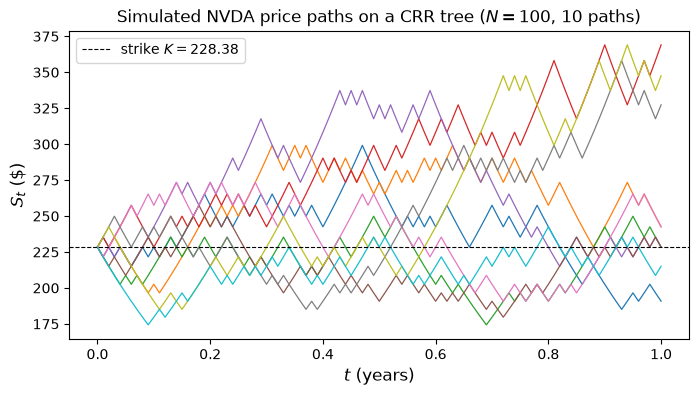

In [24]:
N_plot = 100
t_tree, S_tree = simulate_tree_paths(S0, sigma, r, T, N_plot, n_paths=10, rng=rng)   # notebook's rng → reproducible

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_tree, S_tree.T, linewidth=0.9)          # .T → one line per path
ax.axhline(K, color="black", linestyle="--", linewidth=0.8, label=f"strike $K = {K:.2f}$")
ax.set_xlabel("$t$ (years)", fontsize=12)
ax.set_ylabel("$S_t$ (\\$)", fontsize=12)
ax.set_title(f"Simulated NVDA price paths on a CRR tree ($N = {N_plot}$, 10 paths)", fontsize=12)
ax.legend(loc="upper left")
fig.savefig(FIG_DIR / "part2_tree_paths.pdf", bbox_inches="tight")
plt.show()